# ⚖️ Ejercicio Básico 3 — Concentración gravimétrica
### Mina Río Suri (ficticia) · *Datos simulados*

**Objetivo:** dos cálculos clásicos de gravimetría en pocos pasos:
1. **Criterio de concentración (CC):** ¿qué minerales se pueden separar por gravedad?
2. **Balance de 3 productos** de una prueba en mesa Wilfley.

## Teoría — Criterio de concentración
$$CC = \frac{\rho_{pesado} - \rho_{fluido}}{\rho_{liviano} - \rho_{fluido}}$$

| CC | Separación por gravedad |
|---|---|
| > 2.5 | Fácil (hasta tamaños finos) |
| 1.75 – 2.5 | Posible hasta ~100 µm |
| 1.5 – 1.75 | Difícil (solo grueso) |
| < 1.25 | No viable |

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

xls = "../data/08_gravimetria_rio_suri.xlsx"
minerales = pd.read_excel(xls, sheet_name="densidades_minerales")
mesa = pd.read_excel(xls, sheet_name="prueba_mesa_wilfley")
minerales

,mineral,densidad_g_cm3
0,Oro nativo,19.30
1,Galena,7.50
2,Magnetita,5.20
3,Pirita,5.00
4,Arsenopirita,6.10
5,Cuarzo,2.65


## 1. Criterio de concentración de cada mineral vs cuarzo (ganga)
El mineral liviano de referencia es el **cuarzo** (2.65 g/cm³) y el fluido es **agua** (1.0 g/cm³).

In [2]:
RHO_AGUA = 1.0
rho_ganga = float(minerales.loc[minerales.mineral == "Cuarzo", "densidad_g_cm3"].iloc[0])

pesados = minerales[minerales.mineral != "Cuarzo"].copy()
pesados["CC"] = ((pesados["densidad_g_cm3"] - RHO_AGUA) / (rho_ganga - RHO_AGUA)).round(2)

def facilidad(cc):
    if cc > 2.5: return "Fácil"
    if cc > 1.75: return "Posible hasta ~100 µm"
    if cc > 1.5: return "Difícil"
    return "No viable"

pesados["separacion"] = pesados["CC"].apply(facilidad)
pesados.sort_values("CC", ascending=False)

,mineral,densidad_g_cm3,CC,separacion
0,Oro nativo,19.3,11.09,Fácil
1,Galena,7.5,3.94,Fácil
4,Arsenopirita,6.1,3.09,Fácil
2,Magnetita,5.2,2.55,Fácil
3,Pirita,5.0,2.42,Posible hasta ~100 µm


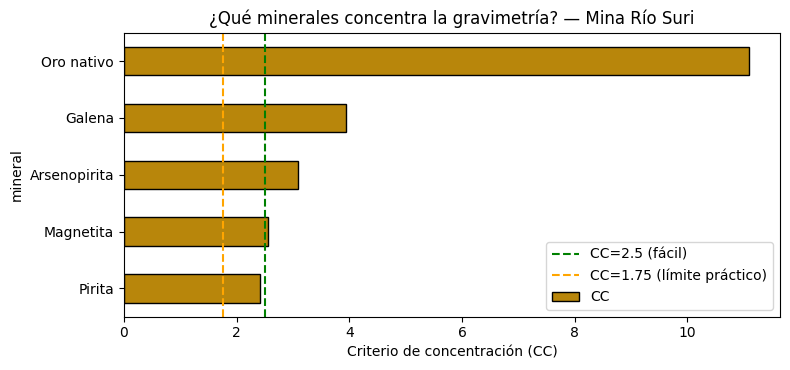

In [3]:
ax = pesados.sort_values("CC").plot(kind="barh", x="mineral", y="CC", legend=False,
                                    color="darkgoldenrod", edgecolor="k", figsize=(8, 3.8))
ax.axvline(2.5, color="green", ls="--", label="CC=2.5 (fácil)")
ax.axvline(1.75, color="orange", ls="--", label="CC=1.75 (límite práctico)")
ax.set_xlabel("Criterio de concentración (CC)")
ax.set_title("¿Qué minerales concentra la gravimetría? — Mina Río Suri")
ax.legend(); plt.tight_layout(); plt.show()

> 💡 El **oro nativo** (CC ≈ 11) es el caso ideal de la gravimetría: por eso los concentradores centrífugos (Knelson/Falcon) recuperan oro grueso antes de la flotación o cianuración.

## 2. Balance de la prueba en mesa Wilfley (3 productos)
Con peso y ley de cada producto calculamos la distribución del oro (¡el balance con pesos reales, sin fórmulas de leyes!):

In [4]:
mesa["contenido_au_mg"] = mesa["peso_kg"] * mesa["ley_au_g_t"]  # kg × g/t = mg
total_au = mesa["contenido_au_mg"].sum()
mesa["distribucion_au_pct"] = (mesa["contenido_au_mg"] / total_au * 100).round(2)
mesa["pct_peso"] = (mesa["peso_kg"] / mesa["peso_kg"].sum() * 100).round(2)

ley_cabeza_calc = total_au / mesa["peso_kg"].sum()
print(f"Ley de cabeza calculada: {ley_cabeza_calc:.2f} g/t")
print(f"Recuperación en concentrado: {mesa.loc[0,'distribucion_au_pct']:.1f} %")
print(f"Ratio de concentración: {mesa['peso_kg'].sum()/mesa.loc[0,'peso_kg']:.0f}:1")
mesa

Ley de cabeza calculada: 8.38 g/t
Recuperación en concentrado: 73.5 %
Ratio de concentración: 62:1


,producto,peso_kg,ley_au_g_t,contenido_au_mg,distribucion_au_pct,pct_peso
0,Concentrado,3.2,385.00,1232.00,73.54,1.6
1,Mixtos (medios),14.6,18.50,270.10,16.12,7.3
2,Relave,182.2,0.95,173.09,10.33,91.1


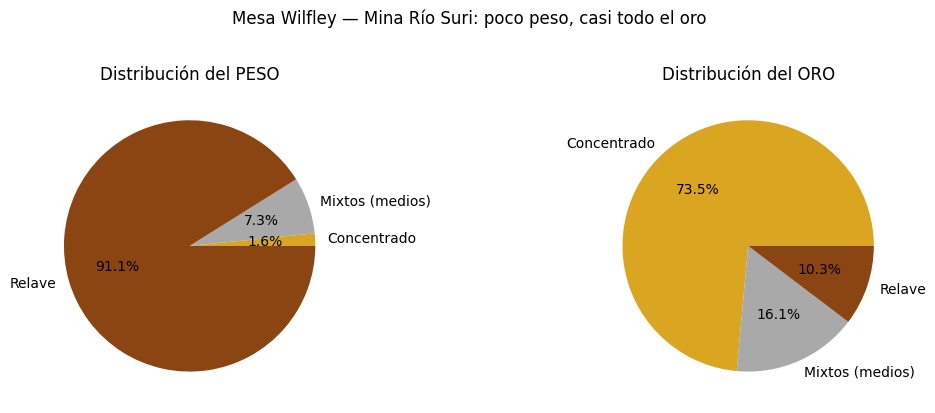

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colores = ["#DAA520", "#A9A9A9", "#8B4513"]
axes[0].pie(mesa["pct_peso"], labels=mesa["producto"], autopct="%1.1f%%", colors=colores)
axes[0].set_title("Distribución del PESO")
axes[1].pie(mesa["distribucion_au_pct"], labels=mesa["producto"], autopct="%1.1f%%", colors=colores)
axes[1].set_title("Distribución del ORO")
plt.suptitle("Mesa Wilfley — Mina Río Suri: poco peso, casi todo el oro", y=1.02)
plt.tight_layout(); plt.show()

## ✅ Conclusiones
1. Con CC > 2.5, el oro, la galena y la arsenopirita son concentrables por gravedad; el cuarzo se descarta como ganga.
2. La mesa concentró ~61 % del oro en solo 1.6 % del peso (ratio ≈ 63:1).
3. El balance por **pesos y leyes medidos** es el más confiable; las fórmulas de leyes se usan cuando no se puede pesar.